In [31]:
%load_ext autoreload

from pathlib import Path
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output
from rich.console import Console
from rich.table import Table
from rich import box
import io
import logging

%autoreload 2
from panoseti_interface import PanosetiRun, PFFSequence
from jax_filters import KERNELS


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
!ls data

obs_Palomar.start_2026-01-20T02:24:17Z.runtype_obs-test.pffd
obs_Palomar.start_2026-02-09T09_46_29Z.runtype_obs-test.pffd
obs_UCB_lab.start_2026-02-28T04:05:41Z.runtype_eng-interleave.pffd
obs_UCB_lab.start_2026-02-28T04:39:10Z.runtype_eng-interleave.pffd
obs_UCB_lab.start_2026-02-28T05:10:46Z.runtype_eng-interleave.pffd


In [33]:
# Usage
test_out_dir = Path("out")
data_dir = Path("data")
# run_dir = "obs_Palomar.start_2026-01-20T02:24:17Z.runtype_obs-test.pffd"
# run_dir = "obs_Palomar.start_2026-02-09T09_46_29Z.runtype_obs-test.pffd"
# run_dir = "obs_UCB_lab.start_2026-02-28T04:39:10Z.runtype_eng-interleave.pffd"
run_dir = "obs_UCB_lab.start_2026-02-28T05:10:46Z.runtype_eng-interleave.pffd"


# 1. Load the Run
run_path = data_dir / run_dir
try:
    run = PanosetiRun(run_path)
except FileNotFoundError:
    print("Run directory not found, check path.")
    exit(1)

print("Available Products:", run.list_products())
# Expected: ['dp_ph1024.bpp_2.module_253', 'dp_ph1024.bpp_2.module_252', ...]

Available Products: ['dp_img16.bpp_2.module_254', 'dp_img8.bpp_1.module_254', 'dp_ph256.bpp_2.module_254']


In [34]:
# run.configs["sw_info"]

KeyError: 'sw_info'

Scanning Timestamps:   0%|          | 0/3 [00:00<?, ?it/s]

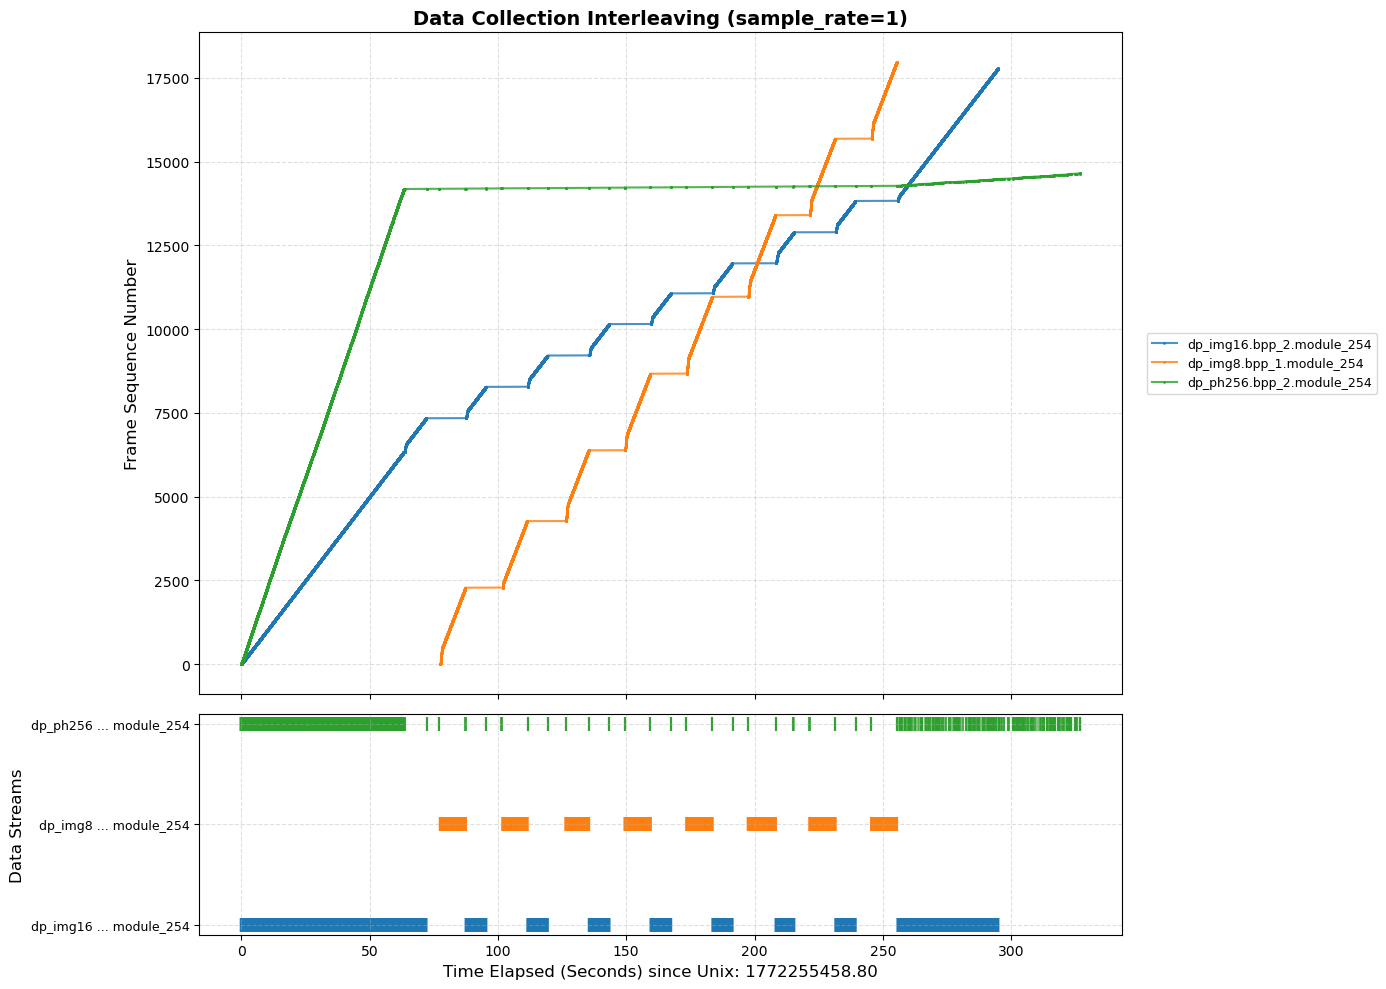

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

def extract_timestamps_rigorous(run_obj, sample_rate=1):
    """
    Extracts timestamps with zero accidental data loss.
    If sample_rate > 1, it will decimate for plotting performance, 
    but mathematically guarantees the first and very last frames are included.
    """
    data = {}
    products = run_obj.list_products()
    
    for prod_name in tqdm(products, desc="Scanning Timestamps"):
        seq = run_obj.get_product(prod_name)
        n_frames = len(seq)
        
        if n_frames == 0:
            continue
            
        times = []
        frames = []
        malformed_count = 0
        
        # 1. Build indices. Force inclusion of the very last frame.
        indices = list(range(0, n_frames, sample_rate))
        if indices[-1] != n_frames - 1:
            indices.append(n_frames - 1)
            
        # 2. Extract strictly
        for i in indices:
            t_ns = seq.get_frame_time(i)
            
            if t_ns > 0:
                times.append(t_ns / 1e9)  # Convert ns to float seconds
                frames.append(i)
            else:
                malformed_count += 1
        
        if times:
            data[prod_name] = {
                'times': np.array(times), 
                'frames': np.array(frames),
                'malformed': malformed_count
            }
            if malformed_count > 0:
                print(f"Warning: {prod_name} had {malformed_count} frames with missing/malformed timestamps.")
                
    return data

# --- 1. Extract Data ---
# Set sample_rate=1 to guarantee EVERY single frame is checked.
# Warning: If you have millions of frames, this may take a moment to compute and render.
timeline_data = extract_timestamps_rigorous(run, sample_rate=1)

if timeline_data:
    # --- 2. Normalize Time ---
    # RIGOROUS FIX: Search the entire array for the absolute chronological minimum
    t0 = min([np.min(d['times']) for d in timeline_data.values() if len(d['times']) > 0])
    
    # --- 3. Plotting ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    
    y_ticks = []
    y_labels = []
    
    for i, (prod_name, d) in enumerate(timeline_data.items()):
        norm_times = d['times'] - t0
        
        # Plot 1: Cumulative Frame vs Time
        ax1.plot(norm_times, d['frames'], marker='.', linestyle='-', markersize=2, label=prod_name, alpha=0.8)
        
        # Plot 2: Gantt / Presence Chart
        ax2.scatter(norm_times, np.full_like(norm_times, i), marker='|', s=100, alpha=0.6)
        
        # Condense labels
        parts = prod_name.split('.')
        short_name = f"{parts[0]} ... {parts[-1]}" if len(parts) > 2 else prod_name
        y_labels.append(short_name)
        y_ticks.append(i)

    # Formatting Top Plot
    ax1.set_ylabel('Frame Sequence Number', fontsize=12)
    ax1.set_title(f'Data Collection Interleaving (sample_rate=1)', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.4, linestyle='--')
    ax1.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
    
    # Formatting Bottom Plot
    ax2.set_yticks(y_ticks)
    ax2.set_yticklabels(y_labels, fontsize=9)
    ax2.set_xlabel(f'Time Elapsed (Seconds) since Unix: {t0:.2f}', fontsize=12)
    ax2.set_ylabel('Data Streams', fontsize=12)
    ax2.grid(True, alpha=0.4, linestyle='--')
    
    plt.tight_layout()
    plt.show()
else:
    print("No valid timeline data found across any products!")